In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import xarray as xr
import numpy as np
import matplotlib
from importlib.resources import files
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.stats import binned_statistic_2d
from scipy.stats import binned_statistic
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

from cloud_filtering.training.surface_algorithm import surface_mask_simulations

plt.style.use('../plotstyling.mplstyle')

In [3]:
db_filename = "../../../DataStorage/AWS/for_cloud_filtering/combined_2025-11-10_2025-12-22_2026-01-20_and_2026-02-05_arcitc_antarctica_training.nc"
ds = xr.open_dataset(db_filename)

In [4]:
NEDeltaT = np.array([0.36, 0.50, 0.56, 0.79, 0.84, 1.0, 0.80, 0.95, 1.53, 1.6])

CS_bins = np.linspace(-10,140,151)

In [5]:
Latitude = ds.Latitude.values

channels = ["AWS31", "AWS32", "AWS33", "AWS34", "AWS35", "AWS36", "AWS44", "AWS43", "AWS42", "AWS41"]

Ta_array = np.zeros((Latitude.shape[0], len(channels)))
for i, ch in enumerate(channels):
    Ta_array[:,i] = ds[f"Ta_Allsky_{ch}"].values

Ta_array_noisy = np.zeros((Latitude.shape[0], len(channels)))
for i, ch in enumerate(channels):
    Ta_array_noisy[:,i] = Ta_array[:,i] + np.random.normal(0, NEDeltaT[i], Ta_array[:,i].shape[0])


CS_array = np.zeros((Latitude.shape[0], len(channels)))
for i, ch in enumerate(channels):
    CS_array[:,i] = ds[f"Ta_Clearsky_{ch}"].values - ds[f"Ta_Allsky_{ch}"].values

CS_array_noisy = np.zeros((Latitude.shape[0], len(channels)))
for i, ch in enumerate(channels):
    CS_array_noisy[:,i] = CS_array[:,i] + np.random.normal(0, NEDeltaT[i], CS_array[:,i].shape[0])

In [6]:
surface_masks = surface_mask_simulations(ds)

m31 = surface_masks[31]
m32 = surface_masks[32]
m33 = surface_masks[33]
m34 = surface_masks[34]
m35 = surface_masks[35]
m36 = surface_masks[36]

model_mask_variants = {
    "aws31_36": (~m31),
    "aws32_36": (~m32),
    "aws33_36": (~m33),
    "aws34_36": (~m34),
    "aws35_36": (~m35),
}

Ta_masked = Ta_array_noisy[model_mask_variants["aws31_36"]]
CS_masked = CS_array[model_mask_variants["aws31_36"]]



In [7]:
model_mask_variants["aws31_36"]

array([ True,  True,  True, ...,  True,  True,  True])

In [8]:
# --- Train a separate Ridge regression model for each target channel ---
models = {}
results = {}

for i, ch in enumerate(channels):
    print(f"Training model for {ch}...")

    X = Ta_masked          # features: all 10 raw TAs
    y = CS_masked[:, i]      # target: cloud signal for this channel

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = Ridge(alpha=1.0)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    models[ch]  = model
    results[ch] = {'rmse': rmse, 'r2': r2}
    print(f"  {ch}: RMSE = {rmse:.4f} K,  R² = {r2:.4f}")


Training model for AWS31...
  AWS31: RMSE = 4.3681 K,  R² = 0.7753
Training model for AWS32...
  AWS32: RMSE = 2.7716 K,  R² = 0.8457
Training model for AWS33...
  AWS33: RMSE = 2.3030 K,  R² = 0.8174
Training model for AWS34...
  AWS34: RMSE = 2.0141 K,  R² = 0.7761
Training model for AWS35...
  AWS35: RMSE = 1.6652 K,  R² = 0.6992
Training model for AWS36...
  AWS36: RMSE = 1.3529 K,  R² = 0.6049
Training model for AWS44...
  AWS44: RMSE = 2.5073 K,  R² = 0.9508
Training model for AWS43...
  AWS43: RMSE = 2.4305 K,  R² = 0.9360
Training model for AWS42...
  AWS42: RMSE = 2.3318 K,  R² = 0.8953
Training model for AWS41...
  AWS41: RMSE = 2.2135 K,  R² = 0.8235


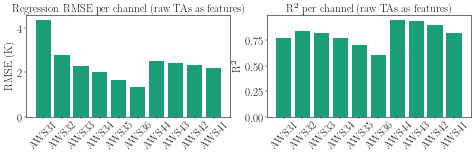

In [9]:

# --- Summary plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

channels = list(results.keys())
rmses = [results[ch]['rmse'] for ch in channels]
r2s   = [results[ch]['r2']   for ch in channels]

axes[0].bar(channels, rmses)
axes[0].set_ylabel('RMSE (K)')
axes[0].set_title('Regression RMSE per channel (raw TAs as features)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(channels, r2s)
axes[1].set_ylabel('R²')
axes[1].set_title('R² per channel (raw TAs as features)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('regression_raw_TAs.png', dpi=150)
plt.show()

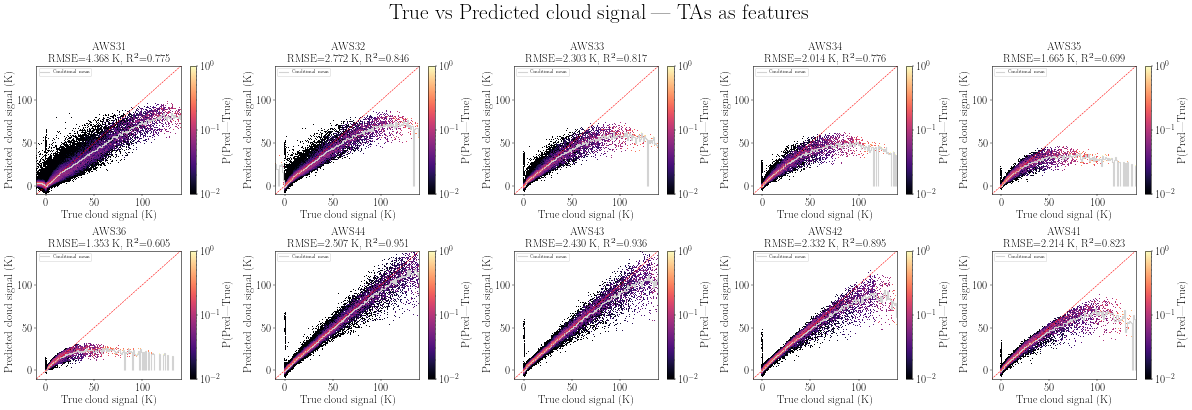

In [18]:
fig, axes = plt.subplots(2, 5, figsize=(30, 10))
axes = axes.flatten()

for i, ch in enumerate(channels):
    X = Ta_masked
    y = CS_masked[:, i]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    y_pred = models[ch].predict(X_test)

    ax = axes[i]


    # joint distribution p(y_true, y_pred)
    p_true_pred, xedges, yedges = np.histogram2d(y_test, y_pred, bins=CS_bins, density=True)

    # marginal distribution p(y_true)
    p_true, _ = np.histogram(y_test, bins=CS_bins, density=True)

    #conditional distribution p(y_pred | y_true)
    p_pred_given_true = np.divide(
        p_true_pred,
        p_true.reshape(-1, 1),
        out=np.full_like(p_true_pred, np.nan),
        where=p_true.reshape(-1, 1) > 0
    )
    
    im = ax.pcolormesh(xedges, yedges, p_pred_given_true.T, cmap='magma',
                       norm=plt.matplotlib.colors.LogNorm(vmin=1e-2, vmax=1e0))
    fig.colorbar(im, ax=ax, label='P(Pred|True)')

    # the conditional mean
    binned_mean = binned_statistic(
        y_test,
        y_pred,
        statistic=np.nanmean,
        bins=CS_bins
    )
    ax.stairs(
        binned_mean.statistic,
        binned_mean.bin_edges,
        label='Conditional mean',
        color='lightgray',
        lw=2
    )
    ax.plot(CS_bins, CS_bins, 'r--', linewidth=1)

    ax.set_xlabel('True cloud signal (K)')
    ax.set_ylabel('Predicted cloud signal (K)')
    ax.set_title(f'{ch}\nRMSE={results[ch]["rmse"]:.3f} K, R²={results[ch]["r2"]:.3f}')
    ax.legend(fontsize=8)

plt.suptitle('True vs Predicted cloud signal — TAs as features', y=1.02)
plt.tight_layout()

plt.savefig("../figures/regression/conditional_probability_raw_Ta.png",
            dpi=200, bbox_inches="tight", facecolor="white")


In [11]:
g3 = Ta_masked[:, :6]   # AWS31-AWS36
g4 = Ta_masked[:, 6:]   # AWS41-AWS44

# Differences between neighbouring channels within each group
within_g3 = np.diff(g3, axis=1)   # AWS32-AWS31, AWS33-AWS32, AWS34-AWS33, AWS35-AWS34, AWS36-AWS35
within_g4 = np.diff(g4, axis=1)   # AWS41-AWS42, AWS42-AWS43, AWS43-AWS44

X_diff = np.hstack([within_g3, within_g4])

models_diff = {}
results_diff = {}

for i, ch in enumerate(channels):
    print(f"Training model for {ch}...")

    y = CS_masked[:, i]

    X_train, X_test, y_train, y_test = train_test_split(
        X_diff, y, test_size=0.2, random_state=42
    )


    model = Ridge(alpha=1.0)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    models_diff[ch]  = model
    results_diff[ch] = {'rmse': rmse, 'r2': r2}
    print(f"  {ch}: RMSE = {rmse:.4f} K,  R² = {r2:.4f}")

Training model for AWS31...
  AWS31: RMSE = 5.6216 K,  R² = 0.6279
Training model for AWS32...
  AWS32: RMSE = 4.2601 K,  R² = 0.6354
Training model for AWS33...
  AWS33: RMSE = 3.6285 K,  R² = 0.5467
Training model for AWS34...
  AWS34: RMSE = 3.1371 K,  R² = 0.4567
Training model for AWS35...
  AWS35: RMSE = 2.4647 K,  R² = 0.3409
Training model for AWS36...
  AWS36: RMSE = 1.8623 K,  R² = 0.2513
Training model for AWS44...
  AWS44: RMSE = 6.2708 K,  R² = 0.6924
Training model for AWS43...
  AWS43: RMSE = 5.9613 K,  R² = 0.6149
Training model for AWS42...
  AWS42: RMSE = 5.1669 K,  R² = 0.4859
Training model for AWS41...
  AWS41: RMSE = 4.2240 K,  R² = 0.3572


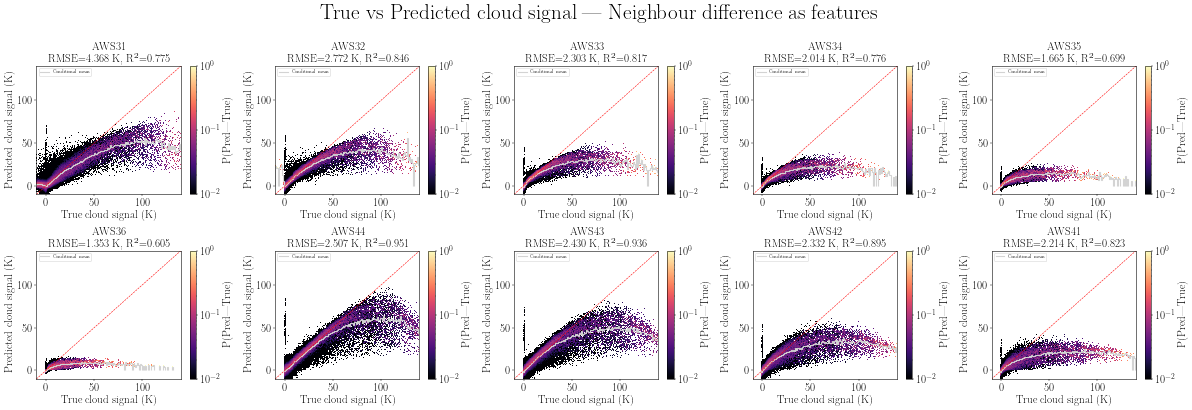

In [17]:
fig, axes = plt.subplots(2, 5, figsize=(30, 10))
axes = axes.flatten()

for i, ch in enumerate(channels):
    X = X_diff
    y = CS_masked[:, i]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    y_pred = models_diff[ch].predict(X_test)

    ax = axes[i]

    # joint distribution p(y_true, y_pred)
    p_true_pred, xedges, yedges = np.histogram2d(y_test, y_pred, bins=CS_bins, density=True)

    # marginal distribution p(y_true)
    p_true, _ = np.histogram(y_test, bins=CS_bins, density=True)

    #conditional distribution p(y_pred | y_true)
    p_pred_given_true = np.divide(
        p_true_pred,
        p_true.reshape(-1, 1),
        out=np.full_like(p_true_pred, np.nan),
        where=p_true.reshape(-1, 1) > 0
    )
    
    im = ax.pcolormesh(xedges, yedges, p_pred_given_true.T, cmap='magma',
                       norm=plt.matplotlib.colors.LogNorm(vmin=1e-2, vmax=1e0))
    fig.colorbar(im, ax=ax, label='P(Pred|True)')

    # the conditional mean
    binned_mean = binned_statistic(
        y_test,
        y_pred,
        statistic=np.nanmean,
        bins=CS_bins
    )
    ax.stairs(
        binned_mean.statistic,
        binned_mean.bin_edges,
        label='Conditional mean',
        color='lightgray',
        lw=2
    )
    ax.plot(CS_bins, CS_bins, 'r--', linewidth=1)

    ax.set_xlabel('True cloud signal (K)')
    ax.set_ylabel('Predicted cloud signal (K)')
    ax.set_title(f'{ch}\nRMSE={results[ch]["rmse"]:.3f} K, R²={results[ch]["r2"]:.3f}')
    ax.legend(fontsize=8)

plt.suptitle('True vs Predicted cloud signal — Neighbour difference as features', y=1.02)
plt.tight_layout()

plt.savefig("../figures/regression/conditional_probability_neighbour_difference.png",
            dpi=200, bbox_inches="tight", facecolor="white")

In [14]:

X_cross = np.column_stack([
    Ta_masked[:, 6] - Ta_masked[:, 2],   # AWS44 - AWS33
    Ta_masked[:, 7] - Ta_masked[:, 3],   # AWS43 - AWS34
    Ta_masked[:, 8] - Ta_masked[:, 4],   # AWS42 - AWS35
    Ta_masked[:, 9] - Ta_masked[:, 5],   # AWS41 - AWS36
])

models_cross = {}
results_cross = {}

for i, ch in enumerate(channels):
    print(f"Training model for {ch}...")

    y = CS_masked[:, i]

    X_train, X_test, y_train, y_test = train_test_split(
        X_cross, y, test_size=0.2, random_state=42
    )

    model = Ridge(alpha=1.0)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    models_cross[ch]  = model
    results_cross[ch] = {'rmse': rmse, 'r2': r2}
    print(f"  {ch}: RMSE = {rmse:.4f} K,  R² = {r2:.4f}")

Training model for AWS31...
  AWS31: RMSE = 5.1911 K,  R² = 0.6827
Training model for AWS32...
  AWS32: RMSE = 3.4239 K,  R² = 0.7645
Training model for AWS33...
  AWS33: RMSE = 2.6342 K,  R² = 0.7611
Training model for AWS34...
  AWS34: RMSE = 2.2056 K,  R² = 0.7314
Training model for AWS35...
  AWS35: RMSE = 1.7754 K,  R² = 0.6580
Training model for AWS36...
  AWS36: RMSE = 1.4252 K,  R² = 0.5615
Training model for AWS44...
  AWS44: RMSE = 2.9205 K,  R² = 0.9333
Training model for AWS43...
  AWS43: RMSE = 2.6988 K,  R² = 0.9211
Training model for AWS42...
  AWS42: RMSE = 2.5448 K,  R² = 0.8753
Training model for AWS41...
  AWS41: RMSE = 2.3957 K,  R² = 0.7932


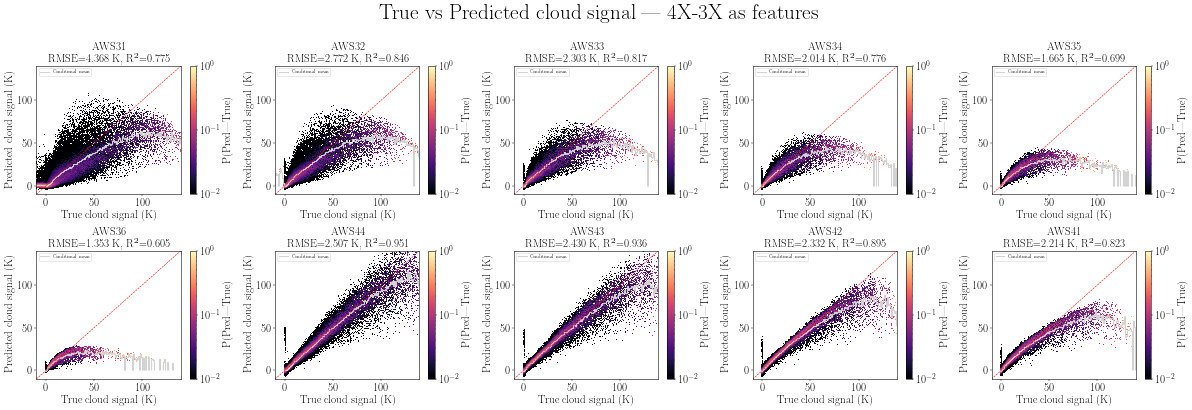

In [16]:
fig, axes = plt.subplots(2, 5, figsize=(30, 10))
axes = axes.flatten()

for i, ch in enumerate(channels):
    X = X_cross
    y = CS_masked[:, i]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    y_pred = models_cross[ch].predict(X_test)

    ax = axes[i]

    # joint distribution p(y_true, y_pred)
    p_true_pred, xedges, yedges = np.histogram2d(y_test, y_pred, bins=CS_bins, density=True)

    # marginal distribution p(y_true)
    p_true, _ = np.histogram(y_test, bins=CS_bins, density=True)

    #conditional distribution p(y_pred | y_true)
    p_pred_given_true = np.divide(
        p_true_pred,
        p_true.reshape(-1, 1),
        out=np.full_like(p_true_pred, np.nan),
        where=p_true.reshape(-1, 1) > 0
    )
    
    im = ax.pcolormesh(xedges, yedges, p_pred_given_true.T, cmap='magma',
                       norm=plt.matplotlib.colors.LogNorm(vmin=1e-2, vmax=1e0))
    fig.colorbar(im, ax=ax, label='P(Pred|True)')

    # the conditional mean
    binned_mean = binned_statistic(
        y_test,
        y_pred,
        statistic=np.nanmean,
        bins=CS_bins
    )
    ax.stairs(
        binned_mean.statistic,
        binned_mean.bin_edges,
        label='Conditional mean',
        color='lightgray',
        lw=2
    )
    ax.plot(CS_bins, CS_bins, 'r--', linewidth=1)

    ax.set_xlabel('True cloud signal (K)')
    ax.set_ylabel('Predicted cloud signal (K)')
    ax.set_title(f'{ch}\nRMSE={results[ch]["rmse"]:.3f} K, R²={results[ch]["r2"]:.3f}')
    ax.legend(fontsize=8)

plt.suptitle('True vs Predicted cloud signal — 4X-3X as features', y=1.02)
plt.tight_layout()

plt.savefig("../figures/regression/conditional_probability_cross_difference.png",
            dpi=200, bbox_inches="tight", facecolor="white")